In [24]:
import os
os.environ["TQDM_DISABLE_WIDGETS"] = "1"  # non garantito su tutte le versioni, da testare

import pandas as pd, matplotlib.pyplot as plt, numpy as np, json, csv
import mne

# sklearn
import sklearn
import sklearn.model_selection

from pypdf import PdfReader
import glob

import kagglehub

# embedding models and chroma vector store
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.prompts import PromptTemplate

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import InferenceClient
from huggingface_hub import model_info

# split text in chunks
from langchain_text_splitters import RecursiveCharacterTextSplitter

from dotenv import load_dotenv
load_dotenv(override=True)  # override=True forza il reload se era già in cache
print(os.getenv("KAGGLE_API_TOKEN") is not None)
print(os.getenv("OPENAI_API_TOKEN") is not None)
print(os.getenv("HF_TOKEN") is not None)

True
True
True


In [25]:
import os
from groq import Groq

client = Groq(api_key=os.getenv("GROQ_API_KEY"))
for m in client.models.list().data:
    print(m.id)

openai/gpt-oss-20b
openai/gpt-oss-safeguard-20b
whisper-large-v3
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m
qwen/qwen3.8-27b
whisper-large-v3-turbo
allam-2-7b
meta-llama/llama-prompt-guard-2-22m
canopylabs/orpheus-v1-english
openai/gpt-oss-120b


In [20]:
Groq().models.list()

NameError: name 'Groq' is not defined

In [2]:
DATA_PATH = '/workspaces/llm_finetuning/FinanceRAG'

if not os.path.exists(DATA_PATH):
    # Download latest version
    path = kagglehub.competition_download('icaif-24-finance-rag-challenge',
                                        output_dir=DATA_PATH)

ACM-ICAIF '24 FinanceRAG Challenge

The Financial RAG Challenge aims to advance Retrieval-Augmented Generation (RAG) systems that can efficiently handle lengthy and complex financial documents. Participants are tasked with building systems capable of retrieving relevant contexts from large financial datasets and generating precise answers to financial queries, addressing real-world challenges such as financial terminology, industry-specific language, and numerical data.

Task 1 (Retrieval):

retrieve the most relevant document chunks (contexts) for a given query from a large document corpus.

The process begins by transforming the query into an embedding, which is then used to search through as pre-indexed vector database containing document embeddings.

Task --> implement an effective retrieval and re-ranking system that can prioritize the top-relevant contexts of the document corpus based on similarity to the query. 

For the Task 1, evaluation of retrieval process will use the NDCG@10 (Normalized Discounted Cumulative Gain) metric. NDCG is a commonly used metric in information retrieval to evaluate the ranking quality of search results. It measures how well the predicted ranking of relevant documents matches the ideal ranking. NDCG@10 specifically evaluates the top 10 results returned for each query.

The goal of Task 1 is to maximize the retrieval accuracy (nDCG@10) by ranking the most relevant contexts in response to each query. Evaluation is based on how well the system ranks the retrieved contexts compared to the ground truth.

#### Load data

RAG dataset including seven financial datasets, that focus both on textual and tabular data.

The selected datasets contain a diverse range of financial terminology, jargon, and industry-specific language, as well as complex numeric data such as tables, which are crucial for financial analysis.

Passage 
-Retrieval:
- FinDER
- FinQABench
- FinanceBench

Tabular and Text Retrieval:
- dd

In [3]:
def open_jsonl(path):
    if os.path.isdir(path):
        path = os.path.join(path, os.listdir(path)[0])
        data = pd.read_json(path, lines=True)
        return data
    with open(path,"r") as file:
            pd.read_json(path, lines=True)
    return data

In [4]:
finder_corpus = open_jsonl(os.path.join(DATA_PATH, 'finder_corpus.jsonl'))
finder_corpus.head(3)

,_id,title,text
0,ADBE20230004,ADBE OVERVIEW,Adobe is a global technology company with a mi...
1,ADBE20230006,ADBE OFFERINGS,"We deliver a wide range of products, services ..."
2,ADBE20230007,ADBE OFFERINGS,"Digital Media. We provide products, services a..."


In [5]:
finder_queries = open_jsonl(os.path.join(DATA_PATH, 'finder_queries.jsonl'))
finder_queries.head(3)

,_id,title,text
0,q00001,,What are the service and product offerings fro...
1,q00002,,MSFT segment breakdown
2,q00003,,Who are Microsoft`s key customers?


In [6]:
# Ground truth
finder_gt = pd.read_csv('/workspaces/llm_finetuning/FinanceRAG/FinDER_qrels.tsv', sep='\t',engine="python", quoting=csv.QUOTE_NONE) 
finder_gt.head(3)


,query_id,corpus_id,score
0,q00001,MSFT20230014,1
1,q00001,MSFT20230015,1
2,q00007,MSFT20231529,1


#### Ingestion

Involves:
- preprocessing the uploaded PDFs or texts into chuncks, 
    which are small sections of the overall document, and converting them into a numerical representation called embeddings.

Text Splitting = process of breaking a long document into smaller, easier-to-handle parts. Instead of giving the entire document to an AI system all at once.

RAG systems rely on vector similarity search to retrieve relevant text chunks from a document database. Without splitting, the entire document is embedded as one large chunk, which reduces retrieval accuracy.

In LangChain we have different TextSplitter classes to split the text.

One way is Text-structured based. As a base, this uses the fact that text data is organised in some hierarchical structure: paragraphs, sentences, words, characters.

We use RecursiveCharacterTextSplitter class in LangChain to split text recursively into smaller units, while trying to keep each chunk size in the given limit.

In [7]:
text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ".", " ", ""],  # Paragraph → Line → Sentence → Word → Character
    chunk_size=1000,
    chunk_overlap=0
)

In [8]:
finder_corpus["chunks"] = finder_corpus["text"].apply(lambda t: text_splitter.split_text(t))
finder_corpus.loc[0]['chunks']

['Adobe is a global technology company with a mission to change the world through personalized digital experiences. For over four decades, Adobe’s innovations have transformed how individuals, teams, businesses, enterprises, institutions, and governments engage and interact across all types of media. Our products, services and solutions are used around the world to imagine, create, manage, deliver, measure, optimize and engage with content across surfaces and fuel digital experiences. We have a diverse user base that includes consumers, communicators, creative professionals, developers, students, small and medium businesses and enterprises. We are also empowering creators by putting the power of artificial intelligence (“AI”) in their hands, and doing so in ways we believe are responsible. Our products and services help unleash creativity, accelerate document productivity and power businesses in a digital world.']

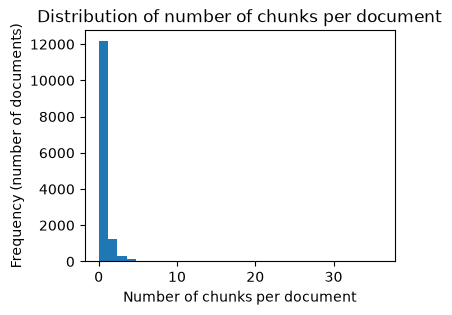

In [9]:
finder_corpus["n_chunks"] = finder_corpus["chunks"].apply(len)

finder_corpus["n_chunks"].describe() 

plt.figure(figsize=(4,3))
plt.hist(finder_corpus["n_chunks"], bins=30)
plt.xlabel("Number of chunks per document")
plt.ylabel("Frequency (number of documents)")
plt.title("Distribution of number of chunks per document")
plt.show()

#### for text data

https://medium.com/@obaadegbokun1/building-finquery-a-rag-system-for-financial-documents-a9f284ecdc15

After chunking, chunks need to be stored as a numerical representation that enables efficient search for chunks similar to the user's query known as embeddings.

In order to convert text (and other forms of data) to embeddings, embedding models are used.


In [10]:
texts = []
metadatas = []

for _, row in finder_corpus.iterrows():
    for chunk in row["chunks"]:
        texts.append(chunk)
        metadatas.append({
            "doc_id": row["_id"],
            "title": row["title"]
        })

In [11]:
#embedding_model = OpenAIEmbeddings(api_key=os.getenv("OPENAI_API_KEY"), model='text-embedding-3-small')

embedding_model = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2',
                                        encode_kwargs={"normalize_embeddings": True},
                                        model_kwargs={"token": os.getenv('HF_TOKEN')},
                                        show_progress=True)
# Create a Chroma vector store and embed the chunks
# texts = list of texts to add to the collection
# metadatas is a list of metadatas
import chromadb

client = chromadb.PersistentClient(path="/workspaces/llm_finetuning/finder_chroma_db")
existing_collections = [c.name for c in client.list_collections()]

if "FinDER_store" in existing_collections:
    print("Collection already existing. Loaded.")
    vector_store = Chroma(
        collection_name="FinDER_store",
        embedding_function=embedding_model,
        persist_directory="/workspaces/llm_finetuning/finder_chroma_db"
    )
    print(f"Chunk già indicizzati: {vector_store._collection.count()}")
else:
    print("Collection not found. Computing embeddings...")
    vector_store = Chroma.from_texts(
        texts=texts,
        collection_name="FinDER_store",
        embedding=embedding_model,
        metadatas=metadatas,
        persist_directory="/workspaces/llm_finetuning/finder_chroma_db"
    )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Collection already existing. Loaded.
Chunk già indicizzati: 16384


In [12]:
# how many chunks are indexed
print(vector_store._collection.count())

16384


In [13]:
results = vector_store.similarity_search_with_score("Are workers represented by labor unions?", k=5)

for doc, score in results:
    print(f"Score: {score:.4f}")
    print(f"Doc ID: {doc.metadata.get('doc_id')}")
    print(f"Text: {doc.page_content[:150]}")
    print("---")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Score: 0.5818
Doc ID: ORCL20230131
Text: None of our employees in the U.S. are represented by labor unions; however, in certain foreign subsidiaries, labor unions or workers’ councils represe
---
Score: 0.6412
Doc ID: DAL20230119
Text: Labor unions periodically engage in organizing efforts to represent various groups of our employees, including at our operating subsidiaries, that are
---
Score: 0.7581
Doc ID: TSLA20230242
Text: It is not uncommon for employees of certain trades at companies such as ours to belong to a union, which can result in higher employee costs and incre
---
Score: 0.8424
Doc ID: MSFT20230424
Text: . The unionization of significant employee populations could result in higher costs and other operational changes necessary to respond to changing con
---
Score: 0.8475
Doc ID: CPNG20230307
Text: Union activities could affect our business.
---


#### RAG Flow

https://medium.com/@harun.kalkanci/retrieval-based-qa-system-with-langchain-and-hugging-face-llm-b764c2fc6a03

In [14]:
# download locally
if False:
    # Initialize the tokenizer and model
    model_id = "microsoft/Phi-4-mini-instruct"
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    llm = AutoModelForCausalLM.from_pretrained(model_id, dtype=torch.bfloat16, device_map="auto")

In [15]:
info = model_info("meta-llama/Llama-3.2-3B-Instruct", expand=["inferenceProviderMapping"])
print(info.inference_provider_mapping)

[InferenceProviderMapping(provider='featherless-ai', hf_model_id='meta-llama/Llama-3.2-3B-Instruct', provider_id='meta-llama/Llama-3.2-3B-Instruct', status='live', task='conversational', adapter=None, adapter_weights_path=None, type=None)]


In [27]:
client = InferenceClient(
    provider="featherless-ai",
    api_key=os.environ["HF_TOKEN"],
)

response = client.chat.completions.create(
    model="meta-llama/Llama-3.2-3B-Instruct",
    messages=[{"role": "user", "content": "Are workers represented by labor unions?"}],
)
print(response.choices[0].message.content)

Yes, many workers in the United States are represented by labor unions. Labor unions are organizations that represent the interests of workers in negotiations with employers over issues such as wages, benefits, working conditions, and job security.

According to data from the Bureau of Labor Statistics (BLS), in 2022:

1. About 10.8% of all employed workers in the United States were members of a labor union.
2. The private sector had a unionization rate of around 9.1%, while the public sector had a rate of around 44.4%.
3. The highest unionization rates were found in the following industries:
 * Public education: 71.4%
 * Public administration: 44.4%
 * Healthcare: 17.1%
 * Manufacturing: 10.4%
4. The largest private sector unions represented workers in the following industries:
 * Healthcare: American Federation of State, County and Municipal Employees (AFSCME)
 * Finance and insurance: American Federation of State, County and Municipal Employees (AFSCME) and the Financial Managers an

In [28]:
info = model_info("meta-llama/Llama-3.2-3B-Instruct", expand=["inferenceProviderMapping"])
print(info.inference_provider_mapping)

[InferenceProviderMapping(provider='featherless-ai', hf_model_id='meta-llama/Llama-3.2-3B-Instruct', provider_id='meta-llama/Llama-3.2-3B-Instruct', status='live', task='conversational', adapter=None, adapter_weights_path=None, type=None)]


#### QA chain

In [48]:
# set chroma vector store as the retriever
# as_retriever function returns vectorStoreRetriever intiialized from this VectorStore
# k = amount of documents to return (default: 4)
retriever = vector_store.as_retriever(search_kwargs={"k": 10})

# create document parsing function to string
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

custom_rag_prompt = PromptTemplate.from_template("""Use the context provided to answer
the user's question below. If you do not know the answer based on the context provided, say so.

context: {context}

question: {question}

answer: """)


def call_llm(prompt_value, **kwargs):
    response = client.chat.completions.create(
        model="meta-llama/Llama-3.2-3B-Instruct",
        messages=[{"role": "user", "content": prompt_value.to_string()}],
    )
    return response.choices[0].message.content

langchain_llm = RunnableLambda(call_llm)

# create the RAG chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | custom_rag_prompt
    | langchain_llm
)

result = rag_chain.invoke("Where are workers under labor unity?")
print(result)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

According to the provided context, workers under labor unions can be found in certain foreign subsidiaries of the company, as well as in the United States. In the US, 20% of the workforce (primarily pilots) is unionized.


In [49]:
# Get an I don't know from the Model
rag_chain.invoke("What is the purpose of life?")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

'The context provided does not explicitly mention the purpose of life. The text primarily discusses the goals, benefits, and mission of Meta, a technology company, without delving into philosophical or existential questions about the purpose of life.'

In [50]:
from langchain_classic.chains import RetrievalQA

In [51]:
langchain_llm = RunnableLambda(call_llm)

retrievalQA = RetrievalQA.from_chain_type(
    llm=langchain_llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True,
    chain_type_kwargs={"prompt": custom_rag_prompt}
)

In [76]:
query = "Where are workers under labor unity?"

In [78]:
# Call the QA chain with our query.
result = retrievalQA.invoke({"query": query})
print(result['result'])

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Workers under labor unions are primarily represented in certain foreign subsidiaries, and in the U.S., some employees are members of labor unions, with a significant percentage being pilots.


In [79]:
relevant_docs = result['source_documents']
relevant_docs

[Document(id='fa7a8027-1ff8-41ef-943f-86a29d8c9a2a', metadata={'title': 'ORCL Workforce', 'doc_id': 'ORCL20230131'}, page_content='None of our employees in the U.S. are represented by labor unions; however, in certain foreign subsidiaries, labor unions or workers’ councils represent some of our employees.'),
 Document(id='5d704857-6bad-47d2-a5c8-31b18b863835', metadata={'title': 'CPNG Risks Related to Labor and Employment', 'doc_id': 'CPNG20230308'}, page_content='The Constitution of the Republic of Korea provides workers with rights to collective bargaining and collective action. Currently, some of our workforce are members of labor unions, with which we are currently negotiating collective bargaining agreements. Unionization of more of our employees or any of our independent delivery partners, actual or threatened strikes, work stoppages or slowdowns may occur and could have an adverse impact on our business, financial condition, or results of operations.'),
 Document(id='c0ce839a-a5

In [80]:
print(f'There are {len(relevant_docs)} documents retrieved which are relevant to the query.')

There are 10 documents retrieved which are relevant to the query.


In [81]:
for i, doc in enumerate(relevant_docs):
    print(f"\nRelevant Document #{i+1}:\nTitle: {doc.metadata['title']}, ID: {doc.metadata['doc_id']}\nContent: {doc.page_content}")
    print("-"*100)


Relevant Document #1:
Title: ORCL Workforce, ID: ORCL20230131
Content: None of our employees in the U.S. are represented by labor unions; however, in certain foreign subsidiaries, labor unions or workers’ councils represent some of our employees.
----------------------------------------------------------------------------------------------------

Relevant Document #2:
Title: CPNG Risks Related to Labor and Employment, ID: CPNG20230308
Content: The Constitution of the Republic of Korea provides workers with rights to collective bargaining and collective action. Currently, some of our workforce are members of labor unions, with which we are currently negotiating collective bargaining agreements. Unionization of more of our employees or any of our independent delivery partners, actual or threatened strikes, work stoppages or slowdowns may occur and could have an adverse impact on our business, financial condition, or results of operations.
------------------------------------------------

In [111]:
finder_corpus

,_id,title,text,chunks,n_chunks
0,ADBE20230004,ADBE OVERVIEW,Adobe is a global technology company with a mi...,[Adobe is a global technology company with a m...,1
1,ADBE20230006,ADBE OFFERINGS,"We deliver a wide range of products, services ...","[We deliver a wide range of products, services...",1
2,ADBE20230007,ADBE OFFERINGS,"Digital Media. We provide products, services a...","[Digital Media. We provide products, services ...",1
3,ADBE20230008,ADBE OFFERINGS,Digital Experience. We provide an integrated p...,[Digital Experience. We provide an integrated ...,1
4,ADBE20230010,ADBE OFFERINGS,"We offer a comprehensive suite of products, se...","[We offer a comprehensive suite of products, s...",1
...,...,...,...,...,...
13862,V20232000,V _______________,† Confidential treatment has been requested fo...,[† Confidential treatment has been requested f...,1
13863,V20232001,V _______________,"* Management contract, compensatory plan or ar...","[* Management contract, compensatory plan or a...",1
13864,V20232004,V _______________,+ Filed or furnished herewith. # Schedules hav...,[+ Filed or furnished herewith. # Schedules ha...,1
13865,V20232012,V SIGNATURES,Pursuant to the requirements of Section 13 or ...,[Pursuant to the requirements of Section 13 or...,1


In [108]:
finder_queries = finder_queries.sort_values(by='_id')
finder_queries.head(7)

,_id,title,text
0,q00001,,What are the service and product offerings fro...
1,q00002,,MSFT segment breakdown
2,q00003,,Who are Microsoft`s key customers?
3,q00004,,What is Microsoft`s business model
4,q00005,,MSFT Capex commitment
5,q00006,,Which recent M&A activities has Microsoft been...
6,q00007,,How much revenue does Microsoft generate from ...


In [88]:
finder_gt = finder_gt.sort_values(by='query_id')
finder_gt.head(3)

,query_id,corpus_id,score
0,q00001,MSFT20230014,1
1,q00001,MSFT20230015,1
2,q00007,MSFT20231529,1


In [107]:
query = finder_queries[finder_queries['_id']=='q00007'].iloc[0]['text']
query

'How much revenue does Microsoft generate from contracts with customers?'

In [110]:
# Call the QA chain with our query.
result = retrievalQA.invoke({"query": query})

relevant_docs = result['source_documents']

for i, doc in enumerate(relevant_docs):
    print(f"\nRelevant Document #{i+1}:\nTitle: {doc.metadata['title']}, ID: {doc.metadata['doc_id']}\nContent: {doc.page_content}")
    print("-"*100)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Relevant Document #1:
Title: MSFT OVERVIEW, ID: MSFT20230482
Content: Highlights from fiscal year 2023 compared with fiscal year 2022 included: •Microsoft Cloud revenue increased 22% to $111.6 billion. •Office Commercial products and cloud services revenue increased 10% driven by Office 365 Commercial growth of 13%. •Office Consumer products and cloud services revenue increased 2% and Microsoft 365 Consumer subscribers increased to 67.0 million. •LinkedIn revenue increased 10%. •Dynamics products and cloud services revenue increased 16% driven by Dynamics 365 growth of 24%. •Server products and cloud services revenue increased 19% driven by Azure and other cloud services growth of 29%. •Windows original equipment manufacturer licensing (“Windows OEM”) revenue decreased 25%. •Devices revenue decreased 24%. •Windows Commercial products and cloud services revenue increased 5%. •Xbox content and services revenue decreased 3%. •Search and news advertising revenue excluding traffic acquisit

#### Tables

https://medium.com/@dev_tips/25-chunking-tricks-for-rag-that-devs-actually-use-12bebd0375bc

Chunking is how you prep documents for retrieval in a RAG system. Since LLMs can’t process entire files (too long, too chaotic), you split your data into smaller, meaningful pieces called chunks that are easy to index, embed, and search.

Chunking sounds simple until you realize bad chunks are why your RAG system keeps returning answers that read like a chatbot having a stroke.
The problem? Loss of context. If your chunk cuts off mid-thought or splits a concept in half, the LLM loses the thread. Too much overlap and it becomes repetitive. Not enough? It becomes clueless. And if you’re blindly chunking by word count or tokens without considering the content yeah, you’re gonna get garbage out.

Core Chunking strategies:

1. Fixed-size chunking (tokens or words): breaks text into equally sized blocks. Simple to implement. Downside: splits can land mid-sentence or mid-paragraph, killing context.
2. Sentence-level chunking: split based on sentence boundaries using punctuation or NLP libs. Pro: chunks make more grammatical sense, improving coherence. Downside: chunks may be too short to be useful alone.
3. Paragraph-level chunking: treat each paragraph as one chunk. Great for structured docs like wikis, blog posts, manuals Downside: Some paragraphs are massive; others too tiny. Inconsistent retrieval quality.
4. Sliding window chunking: creates overlapping chunks. 
5. Recursive chunking: try one method (like paragraph), then fallback to smaller units if the chunk is too big. Supported by tools such as LangChain. 

Classic chunking works fine until the content stops being regular. 
Think messy blogs, technical docs, or transcripts. That’s where semantic chunking steps in splitting text based on meaning, not just size.

Semantic-Aware Chunking (AI knows best):

Table-Aware Chunking

...

